# Single Chain vs Population SAMC

Compare convergence rate of flatness (energy-level exploration) between:
- **1 chain** — standard SAMC
- **5 chains** — population SAMC (shared weights, simultaneous update)

X-axis is **total energy evaluations** (the real computational cost),
so 5 chains × 1000 steps = 5000 evaluations.

In [1]:
import matplotlib.pyplot as plt
import torch

from illuma_samc import SAMCWeights
from illuma_samc.problems.multimodal_2d import energy_fn

In [2]:
# --- Settings ---
T = 0.1
PROPOSAL_STD = 0.05
N_STEPS = 200_000  # per-chain steps
RECORD_EVERY = 200  # record flatness every N energy evals
SEED = 42

## Helper: run SAMC with N chains

Returns `(eval_counts, flatness_values)` where `eval_counts` is cumulative
energy evaluations (the shared x-axis for fair comparison).

In [3]:
def run_samc(
    n_chains: int,
    n_steps: int,
    seed: int,
    save_every: int = 100,
    burn_in: int = 0,
) -> dict:
    """Run population SAMC and track flatness vs total energy evaluations."""
    torch.manual_seed(seed)
    dim = 2

    # Initialize chains
    x = torch.zeros(n_chains, dim)
    fx_batch, _ = energy_fn(x)
    if fx_batch.dim() == 0:
        fx_batch = fx_batch.unsqueeze(0)

    wm = SAMCWeights(record_every=1)  # record every step for fine-grained history

    eval_counts = []  # cumulative energy evaluations
    flatness_vals = []  # flatness at each checkpoint
    all_samples = []  # collected samples for visualization
    best_energy = float("inf")
    accept_count = 0
    total_evals = 0

    for t in range(1, n_steps + 1):
        # Batch propose
        x_new = x + PROPOSAL_STD * torch.randn_like(x)
        fy_batch, in_reg = energy_fn(x_new)
        if fy_batch.dim() == 0:
            fy_batch = fy_batch.unsqueeze(0)
        if in_reg.dim() == 0:
            in_reg = in_reg.unsqueeze(0)

        total_evals += n_chains

        # Batch SAMC correction
        corr = wm.correction(fx_batch, fy_batch)
        if not isinstance(corr, torch.Tensor):
            corr = torch.tensor(corr)

        # Batch log acceptance ratio
        log_r = (-fy_batch.double() + fx_batch.double()) / T + corr.double()

        # Batch accept/reject
        u = torch.rand(n_chains).double()
        accept_mask = in_reg & ((log_r > 0) | (u < torch.exp(log_r.clamp(max=0.0))))

        # Update states
        x[accept_mask] = x_new[accept_mask]
        fx_batch = torch.where(accept_mask, fy_batch, fx_batch)
        accept_count += accept_mask.sum().item()

        # Update shared weights
        wm.step(t, fx_batch)

        # Track best
        step_best = fx_batch.min().item()
        if step_best < best_energy:
            best_energy = step_best

        # Record flatness at checkpoints
        if total_evals % RECORD_EVERY == 0:
            eval_counts.append(total_evals)
            flatness_vals.append(wm.flatness())

        # Collect samples (after burn-in)
        if t > burn_in and t % save_every == 0:
            all_samples.append(x.clone())

    acc_rate = accept_count / (n_steps * n_chains)
    samples = torch.cat(all_samples, dim=0) if all_samples else torch.empty(0, dim)
    return {
        "eval_counts": eval_counts,
        "flatness": flatness_vals,
        "best_energy": best_energy,
        "accept_rate": acc_rate,
        "bins_visited": int((wm.counts > 0).sum().item()),
        "final_flatness": wm.flatness(),
        "wm": wm,
        "samples": samples,
    }

## Run both configurations

Single chain runs `N_STEPS` iterations (N_STEPS energy evals).
5 chains runs `N_STEPS // 5` iterations (same total energy evals).

In [4]:
BURN_IN_FRAC = 0.2  # discard first 20% of steps for sample collection

result_1 = run_samc(
    n_chains=1, n_steps=N_STEPS, seed=SEED,
    burn_in=int(N_STEPS * BURN_IN_FRAC),
)
result_5 = run_samc(
    n_chains=5, n_steps=N_STEPS // 5, seed=SEED,
    burn_in=int(N_STEPS // 5 * BURN_IN_FRAC),
)

f1, f5 = result_1["final_flatness"], result_5["final_flatness"]
e1, e5 = result_1["best_energy"], result_5["best_energy"]
n1, n5 = len(result_1["samples"]), len(result_5["samples"])

print(f"{'':20s} {'1 chain':>12s} {'5 chains':>12s}")
print(f"{'Accept rate':20s} {result_1['accept_rate']:12.3f} {result_5['accept_rate']:12.3f}")
print(f"{'Best energy':20s} {e1:12.3f} {e5:12.3f}")
print(f"{'Bins visited':20s} {result_1['bins_visited']:12d} {result_5['bins_visited']:12d}")
print(f"{'Final flatness':20s} {f1:12.3f} {f5:12.3f}")
evals_1 = result_1["eval_counts"][-1]
evals_5 = result_5["eval_counts"][-1]
print(f"{'Total energy evals':20s} {evals_1:12,d} {evals_5:12,d}")
print(f"{'Samples (post burn)':20s} {n1:12,d} {n5:12,d}")

                          1 chain     5 chains
Accept rate                 0.278        0.276
Best energy                -8.125       -8.125
Bins visited                   17           17
Final flatness              0.836        0.849
Total energy evals        200,000      200,000
Samples (post burn)         1,600        1,600


## Flatness Convergence vs Computation Cost

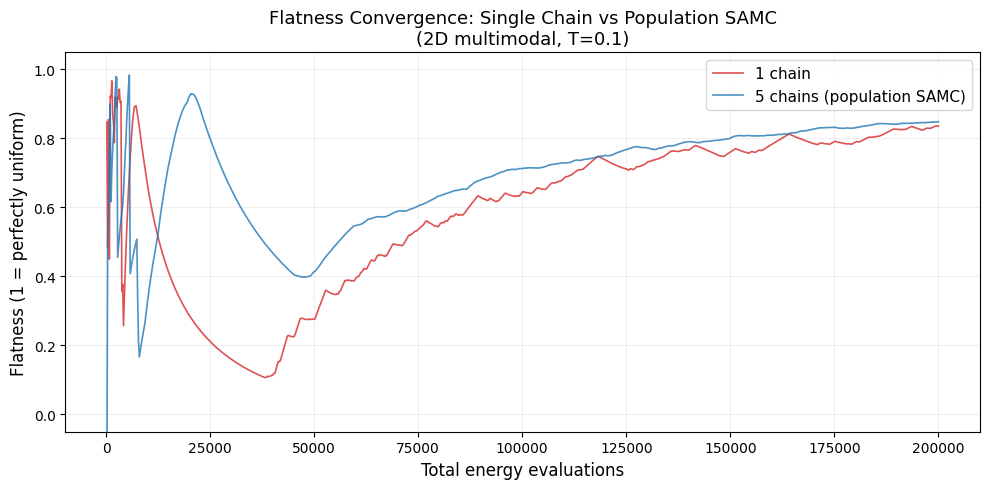

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    result_1["eval_counts"],
    result_1["flatness"],
    label="1 chain",
    color="tab:red",
    linewidth=1.2,
    alpha=0.8,
)
ax.plot(
    result_5["eval_counts"],
    result_5["flatness"],
    label="5 chains (population SAMC)",
    color="tab:blue",
    linewidth=1.2,
    alpha=0.8,
)

ax.set_xlabel("Total energy evaluations", fontsize=12)
ax.set_ylabel("Flatness (1 = perfectly uniform)", fontsize=12)
ax.set_title(
    "Flatness Convergence: Single Chain vs Population SAMC\n(2D multimodal, T=0.1)", fontsize=13
)
ax.legend(fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Bin Visit Histograms (same total cost)

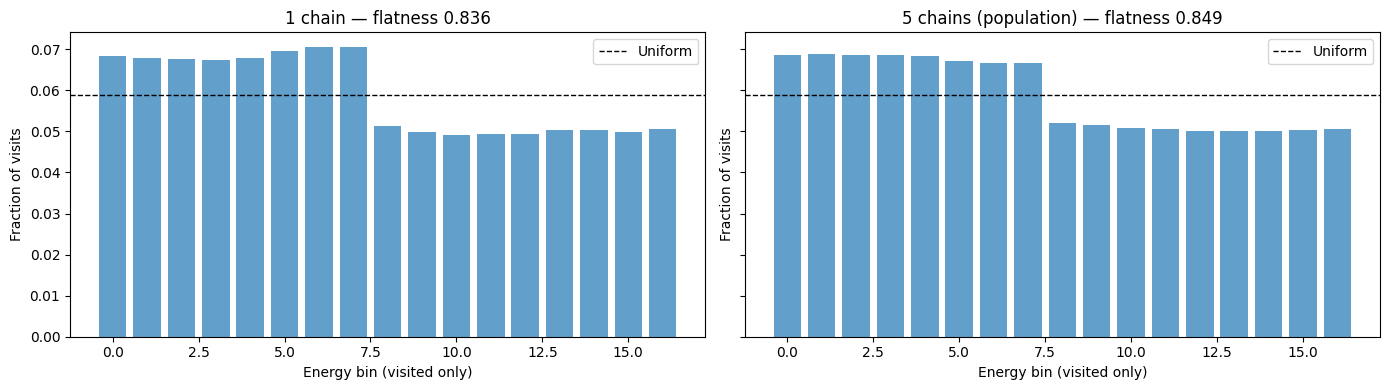

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, result, title in [
    (axes[0], result_1, "1 chain"),
    (axes[1], result_5, "5 chains (population)"),
]:
    c = result["wm"].counts.numpy()
    visited = c > 0
    c_vis = c[visited]
    c_vis = c_vis / max(c_vis.sum(), 1)

    ax.bar(range(len(c_vis)), c_vis, color="tab:blue", alpha=0.7)
    ax.axhline(1.0 / len(c_vis), color="k", ls="--", lw=1, label="Uniform")
    ax.set_title(f"{title} — flatness {result['final_flatness']:.3f}", fontsize=12)
    ax.set_xlabel("Energy bin (visited only)")
    ax.set_ylabel("Fraction of visits")
    ax.legend()

plt.tight_layout()
plt.show()

## Sample Coverage in Domain Space

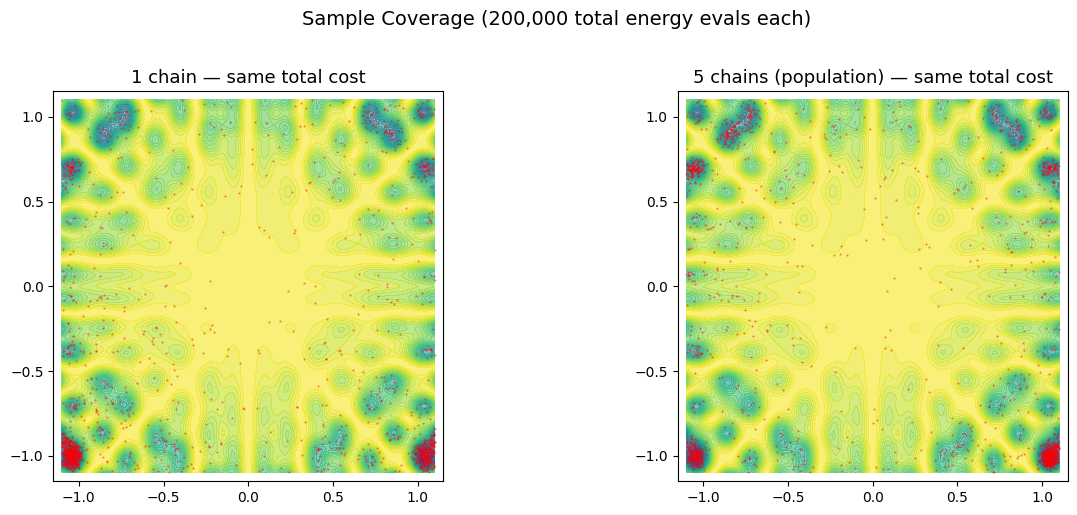

In [7]:
# Energy landscape
grid = torch.linspace(-1.1, 1.1, 200)
X, Y = torch.meshgrid(grid, grid, indexing="ij")
Z_flat = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)
E_grid, _ = energy_fn(Z_flat)
E_grid = E_grid.reshape(200, 200).numpy()
X_np, Y_np = X.numpy(), Y.numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, result, title in [
    (axes[0], result_1, "1 chain"),
    (axes[1], result_5, "5 chains (population)"),
]:
    s = result["samples"].numpy()
    step = max(1, len(s) // 3000)
    sx, sy = s[::step, 0], s[::step, 1]

    ax.contourf(X_np, Y_np, E_grid, levels=40, cmap="viridis", alpha=0.6)
    ax.scatter(sx, sy, c="red", s=0.5, alpha=0.35, zorder=3)
    ax.set_title(f"{title} — same total cost", fontsize=13)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")

plt.suptitle(
    f"Sample Coverage ({N_STEPS:,} total energy evals each)",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()